# Case 1: Regression of Used Car Prices
**Kaggle Playground Series – Season 4, Episode 9**

**Goal:** predict the selling price of a used car from its characteristics (brand, model, year, mileage, engine, etc.).

**Evaluation metric:** Root Mean Squared Error (RMSE), in dollars — the lower, the better.

**Files:**
- `train.csv` – 188,533 cars **with** their price (used to train the models)
- `test.csv` – 125,690 cars **without** price (we must predict it)
- `sample_submission.csv` – example of the format Kaggle expects (`id`, `price`)

## Project plan
1. **Import data** → *question to prof: do we use an API or do we upload the datasets to Databricks?*
2. **Data exploration and cleaning** – look at both datasets: data types, missing values, data cleaning, etc.
3. **Compare different models** to predict the price
4. **Test using the Root Mean Squared Error (RMSE)**
5. **Select one model and create the dataset with the predictions**

---
## 1. Import data
### 1.1 Libraries

In [16]:
# pandas: the main library to load and manipulate tables (DataFrames)
import pandas as pd

### 1.2 Chart style
A few settings so all the charts in this notebook look clean and consistent.

In [17]:
# Chart style used in the whole notebook
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top': False, 'axes.spines.right': False,   # remove the box around the chart
    'axes.grid': True, 'grid.color': '#e6e5e0', 'grid.linewidth': 0.8,
    'axes.axisbelow': True,                                  # grid behind the bars
    'axes.edgecolor': '#9a9993', 'axes.labelcolor': '#52514e',
    'xtick.color': '#52514e', 'ytick.color': '#52514e',
    'axes.titleweight': 'bold', 'axes.titlesize': 12, 'font.size': 10,
})

# Colours: blue = main/selected, orange = second series, grays = context
BLUE, ORANGE, GRAY, LIGHT_GRAY = '#2a78d6', '#eb6834', '#8a8983', '#c9c8c2'

# Axis formatter: 45000 -> $45k
dollars = FuncFormatter(lambda x, _: f'${x/1000:,.0f}k')

### 1.3 Load the datasets
The three CSV files are in the same folder as this notebook, so we can read them directly with `pd.read_csv`.

In [18]:
# Load the three Kaggle files (they're in the same folder as this notebook)
train = pd.read_csv('train.csv')                    # cars WITH price -> to train the models
test = pd.read_csv('test.csv')                      # cars WITHOUT price -> to predict
submission = pd.read_csv('sample_submission.csv')   # template of the file we send to Kaggle

# .shape returns (rows, columns). Test has one column less because 'price' is missing
print('train:', train.shape, '| test:', test.shape)

# Show the first 5 rows to get a feeling of the data
train.head()

train: (188533, 13) | test: (125690, 12)


,id,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,0,MINI,Cooper S Base,2007,213000,Gasoline,172.0HP 1.6L 4 Cylinder Engine Gasoline Fuel,A/T,Yellow,Gray,None reported,Yes,4200
1,1,Lincoln,LS V8,2002,143250,Gasoline,252.0HP 3.9L 8 Cylinder Engine Gasoline Fuel,A/T,Silver,Beige,At least 1 accident or damage reported,Yes,4999
2,2,Chevrolet,Silverado 2500 LT,2002,136731,E85 Flex Fuel,320.0HP 5.3L 8 Cylinder Engine Flex Fuel Capab...,A/T,Blue,Gray,None reported,Yes,13900
3,3,Genesis,G90 5.0 Ultimate,2017,19500,Gasoline,420.0HP 5.0L 8 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,Black,Black,None reported,Yes,45000
4,4,Mercedes-Benz,Metris Base,2021,7388,Gasoline,208.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,7-Speed A/T,Black,Beige,None reported,Yes,97500


---
## 2. Exploratory Data Analysis (EDA) and cleaning
### 2.1 Data types and missing values
First we check which columns are numbers and which are text, and how many values are missing.

In [19]:
# 2.1 Data types and missing values
# .info() shows each column, its data type (int64, float64, object = text) and non-null count
train.info()

# .isna().sum() counts the missing values per column; we only print the columns that have some
print('\nMissing values (train):')
print(train.isna().sum()[train.isna().sum() > 0])
print('\nMissing values (test):')
print(test.isna().sum()[test.isna().sum() > 0])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188533 entries, 0 to 188532
Data columns (total 13 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            188533 non-null  int64 
 1   brand         188533 non-null  object
 2   model         188533 non-null  object
 3   model_year    188533 non-null  int64 
 4   milage        188533 non-null  int64 
 5   fuel_type     183450 non-null  object
 6   engine        188533 non-null  object
 7   transmission  188533 non-null  object
 8   ext_col       188533 non-null  object
 9   int_col       188533 non-null  object
 10  accident      186081 non-null  object
 11  clean_title   167114 non-null  object
 12  price         188533 non-null  int64 
dtypes: int64(4), object(9)
memory usage: 18.7+ MB

Missing values (train):
fuel_type       5083
accident        2452
clean_title    21419
dtype: int64

Missing values (test):
fuel_type       3383
accident        1632
clean_title    14239
dtype

**Findings:**
- Apart from `id`, only 3 numeric columns (`model_year`, `milage`, `price`); the rest are text.
- Missing values in `clean_title` (21,419), `fuel_type` (5,083) and `accident` (2,452).

#### Chart: missing values

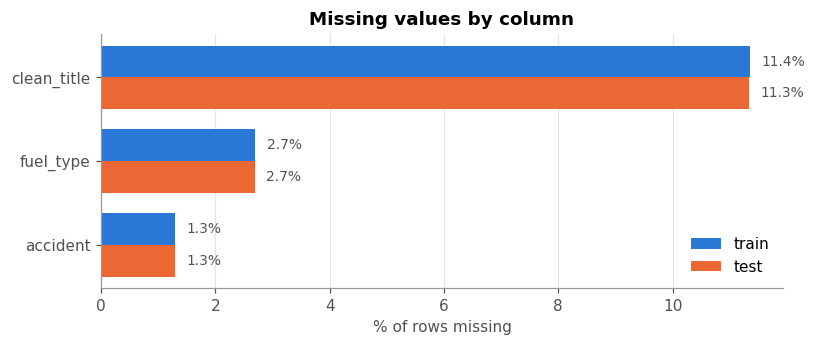

In [20]:
# % of missing values per column, train vs test
miss = pd.DataFrame({'train': train.isna().mean() * 100,
                     'test': test.isna().mean() * 100})
miss = miss[(miss > 0).any(axis=1)].sort_values('train')   # keep only columns with gaps

fig, ax = plt.subplots(figsize=(8, 3))
pos = np.arange(len(miss)); h = 0.38                        # bar positions and height
ax.barh(pos + h/2, miss['train'], height=h, color=BLUE, label='train')
ax.barh(pos - h/2, miss['test'], height=h, color=ORANGE, label='test')
# write the % at the end of each bar
for i, (a, b) in enumerate(zip(miss['train'], miss['test'])):
    ax.text(a + 0.2, i + h/2, f'{a:.1f}%', va='center', fontsize=9, color='#52514e')
    ax.text(b + 0.2, i - h/2, f'{b:.1f}%', va='center', fontsize=9, color='#52514e')
ax.set_yticks(pos, miss.index)
ax.set_xlabel('% of rows missing')
ax.set_title('Missing values by column')
ax.grid(axis='y', visible=False)
ax.legend(frameon=False)
plt.show()

### 2.2 Unique values and categories
How many different values each column has, and what the main categories look like.

In [21]:
# 2.2 How many unique values per column + a look at the categories
# .nunique() = number of different values in each column
print(train.nunique())

# value_counts() lists each category and how many times it appears
# dropna=False also counts the missing values (NaN)
for col in ['fuel_type', 'accident', 'clean_title', 'transmission']:
    print('\n', train[col].value_counts(dropna=False).head(10))

id              188533
brand               57
model             1897
model_year          34
milage            6651
fuel_type            7
engine            1117
transmission        52
ext_col            319
int_col            156
accident             2
clean_title          1
price             1569
dtype: int64

 fuel_type
Gasoline          165940
Hybrid              6832
E85 Flex Fuel       5406
NaN                 5083
Diesel              3955
–                    781
Plug-In Hybrid       521
not supported         15
Name: count, dtype: int64

 accident
None reported                             144514
At least 1 accident or damage reported     41567
NaN                                         2452
Name: count, dtype: int64

 clean_title
Yes    167114
NaN     21419
Name: count, dtype: int64

 transmission
A/T                               49904
8-Speed A/T                       20645
Transmission w/Dual Shift Mode    19255
6-Speed A/T                       18044
6-Speed M/T            

**Findings:**
- `fuel_type` has "fake" values: **"–"** (781 rows) and **"not supported"** (15 rows) → they are really missing values.
- `accident` and `clean_title` only have 2 options each → can be converted to 0/1.
- Some columns have **too many categories** (high cardinality): `model` = 1,897, `engine` = 1,117, `ext_col` = 319. This will matter for the models.
- `engine` is free text (e.g. *"172.0HP 1.6L 4 Cylinder Engine"*) → we can extract numbers from it.

### 2.3 Target variable: `price`

count    1.885330e+05
mean     4.387802e+04
std      7.881952e+04
min      2.000000e+03
25%      1.700000e+04
50%      3.082500e+04
75%      4.990000e+04
max      2.954083e+06
Name: price, dtype: float64


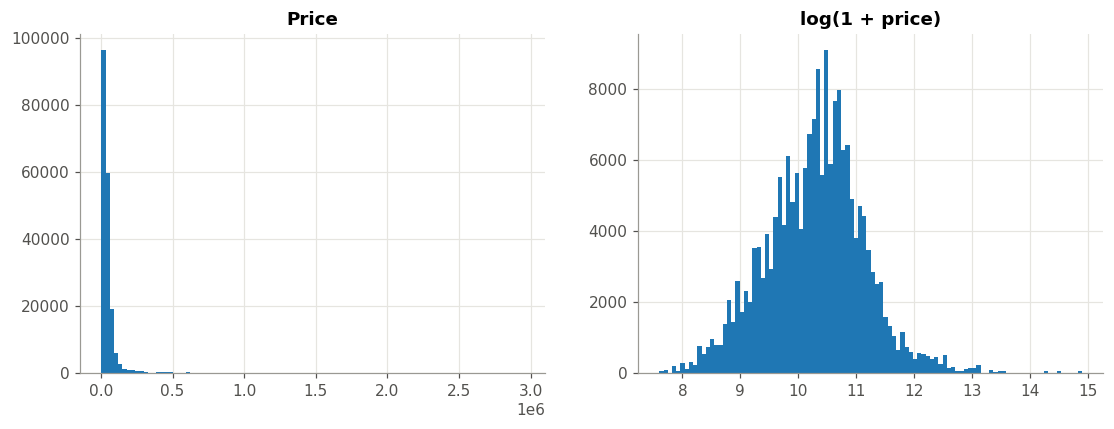

In [22]:
# 2.3 Target variable: price
import numpy as np                  # numerical functions (log, arrays, etc.)
import matplotlib.pyplot as plt     # charts

# Basic statistics: mean, standard deviation, min, quartiles, max
print(train['price'].describe())

# Two histograms side by side: the original price and the log of the price
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(train['price'], bins=100)
ax[0].set_title('Price')
ax[1].hist(np.log1p(train['price']), bins=100)   # log1p(x) = log(1 + x)
ax[1].set_title('log(1 + price)')
plt.show()

**Findings:**
- The price is **very skewed**: median ≈ \$30,800, but the maximum is ≈ \$2.95M.
- A few very expensive cars (outliers) will produce big errors, and RMSE punishes big errors a lot.
- The log of the price looks much more "normal" → we will test training on log(price) too.

### 2.4 Data cleaning and feature engineering
We create one function `clean()` and apply it to **both** train and test, so they receive exactly the same transformations.

| Column | Transformation |
|---|---|
| `fuel_type` | "–" and "not supported" → missing → filled with "Unknown" |
| `accident` | 1 = accident reported, 0 = none / unknown |
| `clean_title` | 1 = "Yes", 0 = missing |
| `engine` | extract new numeric columns `hp`, `liters`, `cylinders` |
| `transmission` | new flag `is_manual` |
| `model_year` | new column `car_age` = 2024 − model_year |

In [23]:
# 2.4 Cleaning + feature engineering (same function applied to train AND test)
def clean(df):
    df = df.copy()   # work on a copy so the original DataFrame is not modified

    # fuel_type: '–' and 'not supported' are really missing values
    df['fuel_type'] = df['fuel_type'].replace({'–': np.nan, 'not supported': np.nan}).fillna('Unknown')

    # accident / clean_title -> 0/1 flags (True/False converted to 1/0 with astype(int))
    df['accident'] = (df['accident'] == 'At least 1 accident or damage reported').astype(int)
    df['clean_title'] = (df['clean_title'] == 'Yes').astype(int)

    # engine text -> numbers, e.g. '172.0HP 1.6L 4 Cylinder Engine'
    # str.extract() uses a regular expression (regex) to pull a pattern out of the text
    df['hp'] = df['engine'].str.extract(r'(\d+\.?\d*)HP').astype(float)         # horsepower: number before 'HP'
    df['liters'] = df['engine'].str.extract(r'(\d+\.?\d*)\s*L').astype(float)   # engine size: number before 'L'
    # cylinders: either '4 Cylinder' or 'V6' -> take whichever of the two patterns was found
    df['cylinders'] = df['engine'].str.extract(r'(\d+) Cylinder|V(\d+)').bfill(axis=1)[0].astype(float)

    # transmission -> manual flag (1 if the text contains 'M/T' or 'Manual')
    df['is_manual'] = df['transmission'].str.contains('M/T|Manual', case=False).astype(int)

    # age of the car (data is from 2024)
    df['car_age'] = 2024 - df['model_year']

    # fill remaining text gaps in the colour columns
    for col in ['ext_col', 'int_col']:
        df[col] = df[col].replace('–', 'Unknown')
    return df

train_c = clean(train)
test_c = clean(test)

# Share of rows where the engine text did not contain the information (NaN)
print(train_c[['hp', 'liters', 'cylinders']].isna().mean().round(3))
train_c.head()

hp           0.176
liters       0.036
cylinders    0.115
dtype: float64


,id,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price,hp,liters,cylinders,is_manual,car_age
0,0,MINI,Cooper S Base,2007,213000,Gasoline,172.0HP 1.6L 4 Cylinder Engine Gasoline Fuel,A/T,Yellow,Gray,0,1,4200,172.0,1.6,4.0,0,17
1,1,Lincoln,LS V8,2002,143250,Gasoline,252.0HP 3.9L 8 Cylinder Engine Gasoline Fuel,A/T,Silver,Beige,1,1,4999,252.0,3.9,8.0,0,22
2,2,Chevrolet,Silverado 2500 LT,2002,136731,E85 Flex Fuel,320.0HP 5.3L 8 Cylinder Engine Flex Fuel Capab...,A/T,Blue,Gray,0,1,13900,320.0,5.3,8.0,0,22
3,3,Genesis,G90 5.0 Ultimate,2017,19500,Gasoline,420.0HP 5.0L 8 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,Black,Black,0,1,45000,420.0,5.0,8.0,0,7
4,4,Mercedes-Benz,Metris Base,2021,7388,Gasoline,208.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,7-Speed A/T,Black,Beige,0,1,97500,208.0,2.0,4.0,0,3


**Result:** `hp` could not be extracted in 17.6% of the rows, `cylinders` in 11.5% and `liters` in 3.6%. This is fine: tree-based models can handle missing values.

### 2.5 Visual exploration: what drives the price?
Four quick charts to see how price relates to the main features.

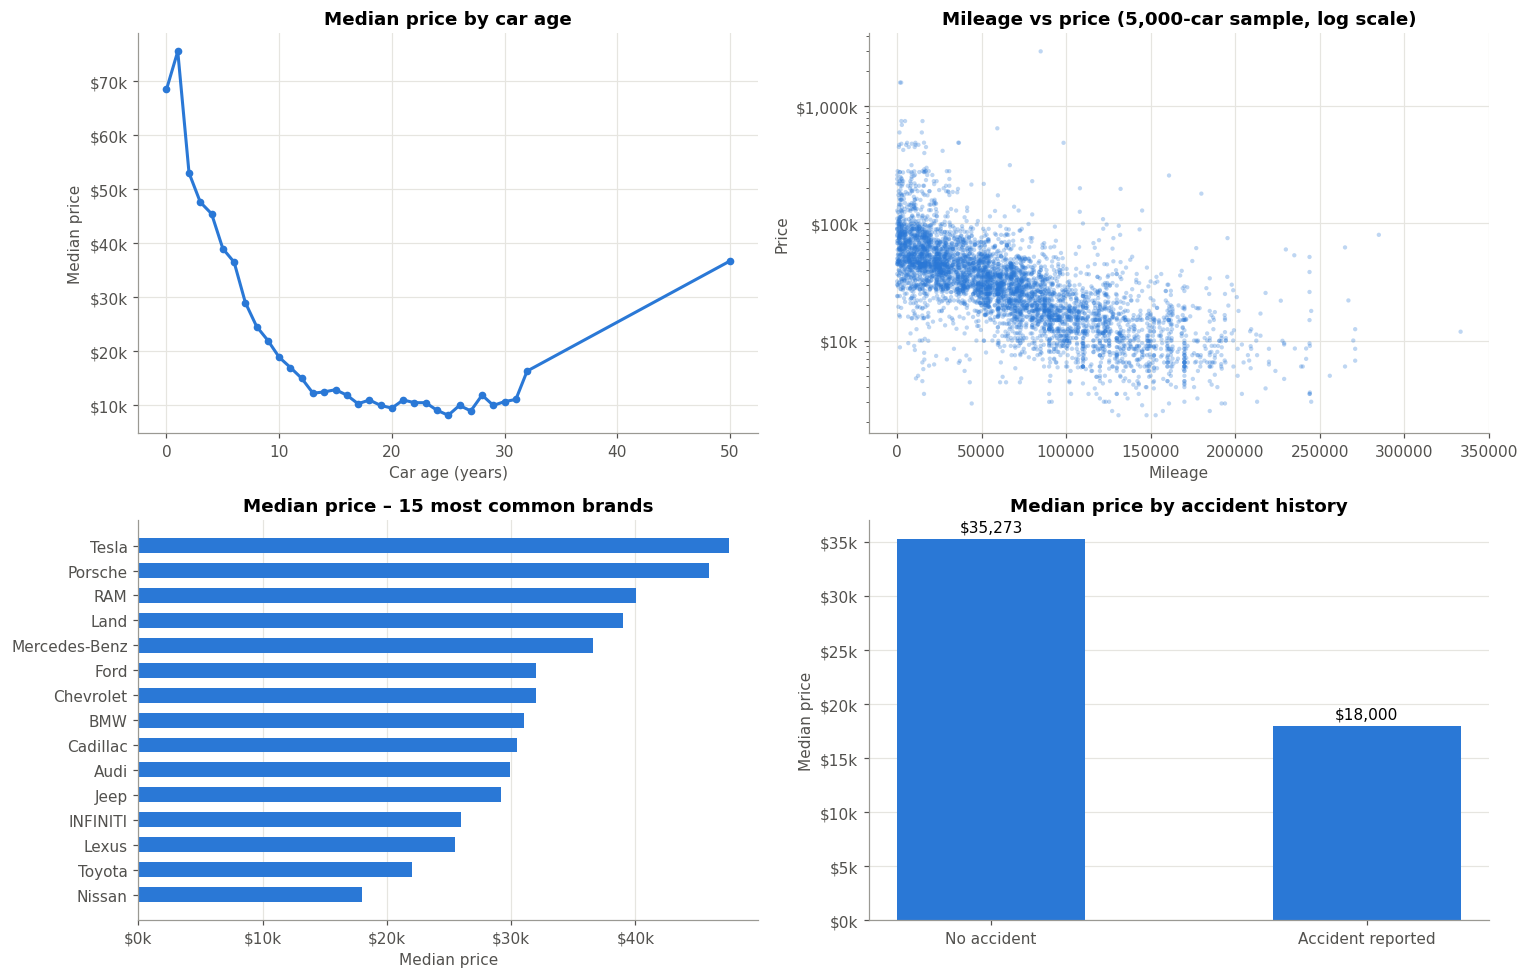

In [24]:
# 2.5 Relationships between price and the main features
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# a) Median price by car age: older cars should be cheaper
age = train_c.groupby('car_age')['price'].median()
ax = axes[0, 0]
ax.plot(age.index, age.values, color=BLUE, lw=2, marker='o', ms=4)
ax.set(title='Median price by car age', xlabel='Car age (years)', ylabel='Median price')
ax.yaxis.set_major_formatter(dollars)

# b) Mileage vs price (random sample of 5,000 cars so the chart is readable)
s = train_c.sample(5000, random_state=42)
ax = axes[0, 1]
ax.scatter(s['milage'], s['price'], s=8, alpha=0.3, color=BLUE, edgecolors='none')
ax.set_yscale('log')   # log scale because of the very expensive cars
ax.set(title='Mileage vs price (5,000-car sample, log scale)', xlabel='Mileage', ylabel='Price')
ax.yaxis.set_major_formatter(dollars)

# c) Median price of the 15 most common brands
top = train_c['brand'].value_counts().head(15).index
b = train_c[train_c['brand'].isin(top)].groupby('brand')['price'].median().sort_values()
ax = axes[1, 0]
ax.barh(b.index, b.values, color=BLUE, height=0.6)
ax.set(title='Median price – 15 most common brands', xlabel='Median price')
ax.xaxis.set_major_formatter(dollars)
ax.grid(axis='y', visible=False)

# d) Accident history: median price with / without accidents
acc = train_c.groupby('accident')['price'].median().rename({0: 'No accident', 1: 'Accident reported'})
ax = axes[1, 1]
bars = ax.bar(acc.index, acc.values, color=BLUE, width=0.5)
ax.bar_label(bars, labels=[f'${v:,.0f}' for v in acc.values], padding=3)
ax.set(title='Median price by accident history', ylabel='Median price')
ax.yaxis.set_major_formatter(dollars)
ax.grid(axis='x', visible=False)

plt.tight_layout()
plt.show()

**Findings:**
- **Age:** the price falls fast in the first ~10 years, then stays flat around \$10k. Very old cars (30+ years) go up again: they are classics/collectibles.
- **Mileage:** clear negative relationship — more miles, lower price.
- **Brand:** among the 15 most common brands, Tesla and Porsche have the highest median prices; Toyota and Nissan the lowest.
- **Accidents:** cars with a reported accident have a median price of \$18,000 vs \$35,273 without — almost half.

---
## 3. Compare different models
### 3.0 Check the installed libraries

In [25]:
# Check which ML libraries are installed (and their versions)
import importlib
for lib in ['sklearn', 'lightgbm', 'xgboost', 'catboost']:
    try:
        m = importlib.import_module(lib); print(lib, m.__version__)
    except ImportError:
        print(lib, 'NOT installed')

sklearn 1.6.1
lightgbm 4.6.0
xgboost 3.0.5
catboost NOT installed


### 3.1 Features and train/validation split
- **Numeric features:** year, age, mileage, hp, liters, cylinders and the 0/1 flags.
- **Categorical features:** brand, model, fuel type, engine, transmission and colours.
- We keep **20% of train as validation**: the model never sees these cars during training, so the RMSE on them shows how well it predicts *new* cars.
- **Baseline:** always predict the average price. Every real model must beat it.

In [26]:
# 3.1 Prepare features and a train/validation split
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error

# Columns the models will use
num_cols = ['model_year', 'car_age', 'milage', 'hp', 'liters', 'cylinders',
            'accident', 'clean_title', 'is_manual']
cat_cols = ['brand', 'model', 'fuel_type', 'engine', 'transmission', 'ext_col', 'int_col']
features = num_cols + cat_cols

X = train_c[features].copy()        # inputs (features)
X_test = test_c[features].copy()
y = train_c['price']                # what we want to predict (target)

# 'category' dtype: tree models like LightGBM can use these text columns directly
# We use the categories of train + test together, so both get the same codes
for col in cat_cols:
    all_cats = pd.concat([X[col], X_test[col]]).astype('category').cat.categories
    X[col] = pd.Categorical(X[col], categories=all_cats)
    X_test[col] = pd.Categorical(X_test[col], categories=all_cats)

# Hold out 20% of train to measure RMSE on cars the model has never seen
# random_state=42 makes the split reproducible (same result every run)
X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
print('train:', X_tr.shape, '| validation:', X_val.shape)

results = {}  # we'll store each model's RMSE here

# Baseline: always predict the average price. Any real model must beat this.
results['Baseline (mean)'] = root_mean_squared_error(y_val, np.full(len(y_val), y_tr.mean()))
results

train: (150826, 16) | validation: (37707, 16)


{'Baseline (mean)': 74573.05090417106}

### 3.2 Model 1: Linear Regression (Ridge)
A simple linear model. It only accepts numbers, so we fill the missing values with the median and apply **one-hot encoding** (one 0/1 column per category) to `brand` and `fuel_type`. It is trained on **log(price)** because linear models work better with a less skewed target.

In [27]:
# 3.2 Model 1: Linear Regression (Ridge)
# Linear models need numbers only: fill numeric gaps with the median,
# one-hot encode the low-cardinality text columns
from sklearn.linear_model import Ridge

def linear_features(df, ref):
    # ref = training data: medians always come from train to avoid data leakage
    out = df[num_cols].fillna(ref[num_cols].median())
    dummies = pd.get_dummies(df[['brand', 'fuel_type']].astype(str), drop_first=True)
    return pd.concat([out, dummies], axis=1)

L_tr = linear_features(X_tr, X_tr)
# reindex: make sure validation has exactly the same columns as train
L_val = linear_features(X_val, X_tr).reindex(columns=L_tr.columns, fill_value=0)

ridge = Ridge(alpha=1.0)                       # alpha = regularization strength
ridge.fit(L_tr, np.log1p(y_tr))                 # train on log(price)
pred = np.expm1(ridge.predict(L_val))          # convert back to dollars (inverse of log1p)
results['Ridge (log target)'] = root_mean_squared_error(y_val, pred)
results

{'Baseline (mean)': 74573.05090417106, 'Ridge (log target)': 69924.65422079661}

### 3.3 Model 2: Random Forest
Many decision trees trained on random samples of the data; the final prediction is the average of all the trees. Trees don't need scaling, so the text columns are just converted to integer codes.

In [28]:
# 3.3 Model 2: Random Forest
# Trees don't need scaling; text categories become integer codes, NaN -> -1
from sklearn.ensemble import RandomForestRegressor

def tree_codes(df):
    out = df.copy()
    for col in cat_cols:
        out[col] = out[col].cat.codes   # each category -> an integer
    return out.fillna(-1)               # scikit-learn trees need no NaN here

rf = RandomForestRegressor(n_estimators=100,      # number of trees
                           max_depth=12,          # max depth of each tree (limits overfitting)
                           min_samples_leaf=20,   # at least 20 cars per final leaf
                           n_jobs=-1,             # use all CPU cores
                           random_state=42)
rf.fit(tree_codes(X_tr), y_tr)
results['Random Forest'] = root_mean_squared_error(y_val, rf.predict(tree_codes(X_val)))
results

{'Baseline (mean)': 74573.05090417106,
 'Ridge (log target)': 69924.65422079661,
 'Random Forest': 68001.25519752306}

### 3.4 Model 3: LightGBM (gradient boosting)
Boosting builds trees **one after another**, each one correcting the errors of the previous ones. LightGBM can use the `category` columns directly. We test two versions: trained on the price in dollars and on log(price).

**Early stopping:** training stops when the validation RMSE hasn't improved for 100 trees.

In [29]:
# 3.4 Model 3: LightGBM (gradient boosting) - uses the category columns directly
import lightgbm as lgb

params = dict(n_estimators=2000,        # max number of trees (early stopping picks the best)
              learning_rate=0.03,       # how much each new tree corrects (small = slower but safer)
              num_leaves=64,            # complexity of each tree
              min_child_samples=50,     # min cars per leaf
              subsample=0.8, subsample_freq=1,   # each tree sees 80% of the rows
              colsample_bytree=0.7,     # each tree sees 70% of the columns
              reg_lambda=1.0,           # L2 regularization
              verbose=-1, random_state=42)

# a) trained on price in dollars
lgb_raw = lgb.LGBMRegressor(**params)
lgb_raw.fit(X_tr, y_tr, eval_set=[(X_val, y_val)],
            callbacks=[lgb.early_stopping(100, verbose=False)])
results['LightGBM (raw price)'] = root_mean_squared_error(y_val, lgb_raw.predict(X_val))

# b) trained on log(price), converted back to dollars
lgb_log = lgb.LGBMRegressor(**params)
lgb_log.fit(X_tr, np.log1p(y_tr), eval_set=[(X_val, np.log1p(y_val))],
            callbacks=[lgb.early_stopping(100, verbose=False)])
results['LightGBM (log target)'] = root_mean_squared_error(y_val, np.expm1(lgb_log.predict(X_val)))

# number of trees kept by early stopping
print('best iterations:', lgb_raw.best_iteration_, lgb_log.best_iteration_)
results

best iterations: 87 158


{'Baseline (mean)': 74573.05090417106,
 'Ridge (log target)': 69924.65422079661,
 'Random Forest': 68001.25519752306,
 'LightGBM (raw price)': 68182.77392307458,
 'LightGBM (log target)': 68675.58940520315}

**Observation:** LightGBM stopped after only **87 trees** → it is **overfitting** (memorizing) the columns with huge numbers of categories (`model`, `engine`). Also, **log(price) gives a worse RMSE**: it compresses the expensive cars, so the model under-predicts them, and RMSE is measured in dollars.

### 3.5 LightGBM v2 and Model 4: XGBoost
Fix for the overfitting: keep only the small categorical columns as `category` and convert the high-cardinality ones to simple integer codes. XGBoost is trained with the same features.

In [30]:
# 3.5 LightGBM stopped very early (87 trees) -> it overfits the huge categories
# (1,897 models, 1,117 engines). Fix: keep only small categories as 'category',
# turn the big ones into plain integer codes.
high_card = ['model', 'engine', 'ext_col', 'int_col', 'transmission']

def lgb_features(df):
    out = df.copy()
    for col in high_card:
        out[col] = out[col].cat.codes   # high-cardinality text -> integer code
    return out

lgb_v2 = lgb.LGBMRegressor(**params)
lgb_v2.fit(lgb_features(X_tr), y_tr, eval_set=[(lgb_features(X_val), y_val)],
           callbacks=[lgb.early_stopping(100, verbose=False)])
results['LightGBM v2 (codes)'] = root_mean_squared_error(y_val, lgb_v2.predict(lgb_features(X_val)))

# 3.6 Model 4: XGBoost on the same features
import xgboost as xgb
xgb_model = xgb.XGBRegressor(n_estimators=2000, learning_rate=0.03,
                             max_depth=6,                # depth of each tree
                             subsample=0.8, colsample_bytree=0.7,
                             min_child_weight=20,        # min "weight" (cars) per leaf
                             early_stopping_rounds=100,  # stop if no improvement in 100 trees
                             enable_categorical=True,    # use the 'category' columns directly
                             tree_method='hist', random_state=42)
xgb_model.fit(lgb_features(X_tr), y_tr, eval_set=[(lgb_features(X_val), y_val)], verbose=False)
results['XGBoost'] = root_mean_squared_error(y_val, xgb_model.predict(lgb_features(X_val)))

# Final comparison table, best (lowest RMSE) first
pd.Series(results, name='RMSE ($)').sort_values().round(0).to_frame()

,RMSE ($)
XGBoost,67756.0
LightGBM v2 (codes),67812.0
Random Forest,68001.0
LightGBM (raw price),68183.0
LightGBM (log target),68676.0
Ridge (log target),69925.0
Baseline (mean),74573.0


### 3.6 Model comparison summary
| Model | Validation RMSE (\$) |
|---|---|
| **XGBoost** | **67,756** |
| LightGBM v2 (codes) | 67,812 |
| Random Forest | 68,001 |
| LightGBM (raw price) | 68,183 |
| LightGBM (log target) | 68,676 |
| Ridge (log target) | 69,925 |
| Baseline (mean) | 74,573 |

- All models beat the baseline; the tree models are very close to each other.
- The data is **noisy**: similar cars have very different prices, and a few cars cost > \$1M.
- **Selected model: XGBoost** (lowest RMSE).

### 3.7 Chart: model comparison
Each dot is one model's RMSE on the validation set. **Lower (further left) is better.** The dashed line is the baseline.

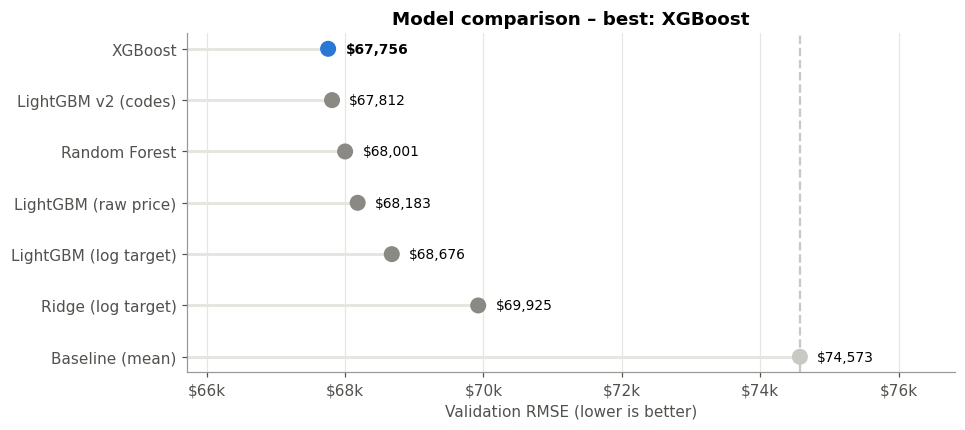

XGBoost                  9.1 % better than baseline
LightGBM v2 (codes)      9.1 % better than baseline
Random Forest            8.8 % better than baseline
LightGBM (raw price)     8.6 % better than baseline
LightGBM (log target)    7.9 % better than baseline
Ridge (log target)       6.2 % better than baseline
dtype: object


In [31]:
# 3.7 Visual comparison of all models
res = pd.Series(results).sort_values(ascending=False)   # best model ends up on top
best = res.idxmin()
colors = [BLUE if m == best else (LIGHT_GRAY if m.startswith('Baseline') else GRAY) for m in res.index]

fig, ax = plt.subplots(figsize=(9, 4))
pos = np.arange(len(res))
ax.hlines(pos, res.min() * 0.97, res.values, color='#e6e5e0', lw=2)      # lollipop stick
ax.scatter(res.values, pos, s=90, color=colors, zorder=3)              # the dot = RMSE
for i, v in enumerate(res.values):
    ax.text(v + 250, i, f'${v:,.0f}', va='center', fontsize=9,
            fontweight='bold' if res.index[i] == best else 'normal')
ax.axvline(results['Baseline (mean)'], color=LIGHT_GRAY, ls='--', lw=1.5)
ax.set_yticks(pos, res.index)
ax.set_xlim(res.min() * 0.97, res.max() * 1.03)
ax.xaxis.set_major_formatter(dollars)
ax.set_xlabel('Validation RMSE (lower is better)')
ax.set_title(f'Model comparison – best: {best}')
ax.grid(axis='y', visible=False)
plt.show()

# How much each model improves vs the baseline
improvement = (1 - pd.Series(results) / results['Baseline (mean)']) * 100
print(improvement.drop('Baseline (mean)').sort_values(ascending=False).round(1).astype(str) + ' % better than baseline')

### 3.8 Inside the best model: feature importance and predictions
- **Feature importance:** which columns XGBoost relied on most (share of the total "gain", i.e. how much each column helped reduce the error).
- **Predicted vs actual:** each dot is a validation car. Dots on the orange line are perfect predictions.

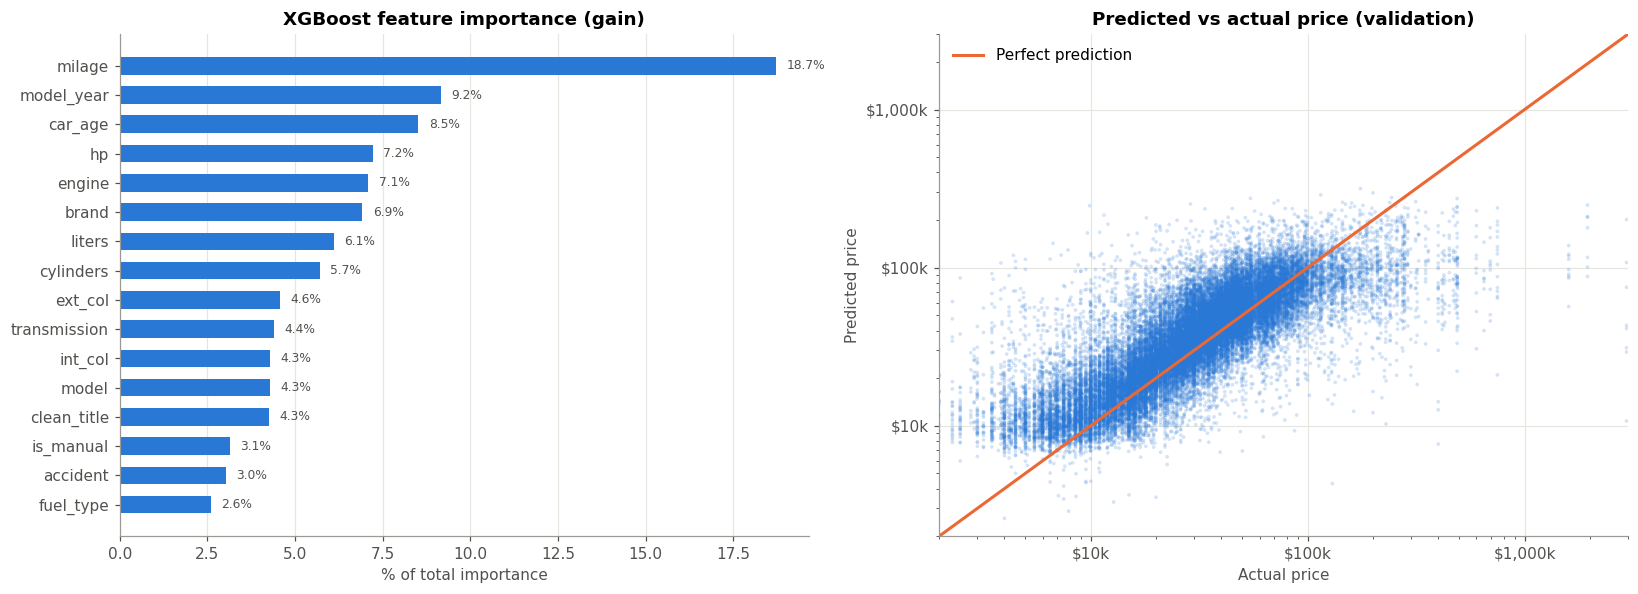

In [32]:
# 3.8 Feature importance + predicted vs actual (XGBoost, validation set)
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# a) Feature importance (gain), as % of the total
imp = pd.Series(xgb_model.get_booster().get_score(importance_type='gain'))
imp = (imp / imp.sum() * 100).sort_values()
ax = axes[0]
ax.barh(imp.index, imp.values, color=BLUE, height=0.6)
for i, v in enumerate(imp.values):
    ax.text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=8, color='#52514e')
ax.set(title='XGBoost feature importance (gain)', xlabel='% of total importance')
ax.grid(axis='y', visible=False)

# b) Predicted vs actual price, log scale on both axes
val_pred = xgb_model.predict(lgb_features(X_val))
ax = axes[1]
ax.scatter(y_val, val_pred, s=6, alpha=0.2, color=BLUE, edgecolors='none')
lims = [2000, 3_000_000]
ax.plot(lims, lims, color=ORANGE, lw=2, label='Perfect prediction')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set(xlim=lims, ylim=lims, title='Predicted vs actual price (validation)',
       xlabel='Actual price', ylabel='Predicted price')
ax.xaxis.set_major_formatter(dollars); ax.yaxis.set_major_formatter(dollars)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

**Findings:**
- **Mileage** is by far the most important feature (~19%), followed by **model_year** and **car_age**. Our engineered features `hp`, `liters` and `cylinders` are also in the top 8.
- The dots follow the orange line, so the model has learned the general pattern.
- But for **expensive cars (> \$200k) most dots are below the line**: the model *under-predicts* them. For cheap cars it tends to *over-predict*. This is where most of the RMSE comes from.

---
## 4. Test using RMSE: 5-fold cross-validation
One single 80/20 split can be lucky or unlucky. With **K-Fold cross-validation** the data is divided in 5 parts; each part is used once as validation, and we average the 5 RMSEs. This gives a more reliable estimate of the real error.

In [33]:
# 4. Validate the chosen model (XGBoost) with 5-fold cross-validation
# Each fold: train on 80%, measure RMSE on the other 20%. Every row gets validated once.
# We also let each fold's model predict the test set and average the 5 predictions.
from sklearn.model_selection import KFold

X_all = lgb_features(X)              # all training rows with the v2 features
X_test_all = lgb_features(X_test)    # test rows with the same features

kf = KFold(n_splits=5, shuffle=True, random_state=42)
fold_rmse = []                        # RMSE of each fold
test_pred = np.zeros(len(X_test_all)) # running average of the test predictions

for fold, (tr_idx, val_idx) in enumerate(kf.split(X_all), start=1):
    model = xgb.XGBRegressor(n_estimators=2000, learning_rate=0.03, max_depth=6,
                             subsample=0.8, colsample_bytree=0.7, min_child_weight=20,
                             early_stopping_rounds=100, enable_categorical=True,
                             tree_method='hist', random_state=42)
    # train on 4 parts, validate on the remaining part
    model.fit(X_all.iloc[tr_idx], y.iloc[tr_idx],
              eval_set=[(X_all.iloc[val_idx], y.iloc[val_idx])], verbose=False)
    rmse = root_mean_squared_error(y.iloc[val_idx], model.predict(X_all.iloc[val_idx]))
    fold_rmse.append(rmse)
    # each fold model contributes 1/5 of the final test prediction
    test_pred += model.predict(X_test_all) / kf.n_splits
    print(f'Fold {fold}: RMSE = {rmse:,.0f}  (trees used: {model.best_iteration})')

print(f'\nCV RMSE: {np.mean(fold_rmse):,.0f} +/- {np.std(fold_rmse):,.0f}')

Fold 1: RMSE = 67,739  (trees used: 179)
Fold 2: RMSE = 68,533  (trees used: 106)
Fold 3: RMSE = 73,872  (trees used: 99)
Fold 4: RMSE = 76,295  (trees used: 201)
Fold 5: RMSE = 76,240  (trees used: 199)

CV RMSE: 72,536 +/- 3,706


**Result:** CV RMSE = **\$72,536 ± \$3,706**. The error changes a lot between folds (\$67.7k to \$76.3k) depending on how many of the rare, very expensive cars fall in each validation part. This is the number we expect on the Kaggle leaderboard.

#### Chart: RMSE per fold

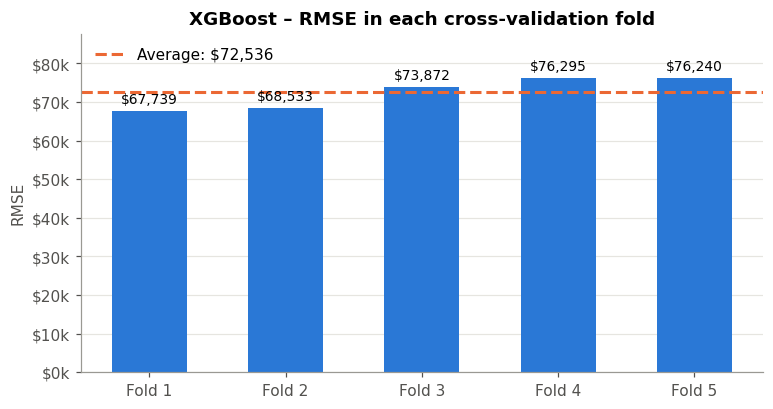

In [37]:
# RMSE of each cross-validation fold vs the average
fig, ax = plt.subplots(figsize=(8, 4))
names = [f'Fold {i}' for i in range(1, len(fold_rmse) + 1)]
bars = ax.bar(names, fold_rmse, color=BLUE, width=0.55)
ax.bar_label(bars, labels=[f'${v:,.0f}' for v in fold_rmse], padding=3, fontsize=9)
ax.axhline(np.mean(fold_rmse), color=ORANGE, lw=2, ls='--',
           label=f'Average: ${np.mean(fold_rmse):,.0f}')
ax.set_ylim(0, max(fold_rmse) * 1.15)
ax.yaxis.set_major_formatter(dollars)
ax.set(title='XGBoost – RMSE in each cross-validation fold', ylabel='RMSE')
ax.grid(axis='x', visible=False)
ax.legend(frameon=False, loc='upper left')
plt.show()

---
## 5. Final predictions and submission file
The final prediction for each test car is the **average of the 5 fold models** (more stable than a single model). Negative predictions are not possible, so values are clipped at 0.

In [35]:
# 5. Create the submission file with the predictions
# np.clip(..., 0, None): replace any negative prediction with 0
submission = pd.DataFrame({'id': test['id'], 'price': np.clip(test_pred, 0, None)})
submission.to_csv('submission.csv', index=False)   # index=False: don't save the row numbers

print(submission.shape)                        # should be (125690, 2)
print(submission['price'].describe().round(0)) # sanity check of the predicted prices
submission.head()

(125690, 2)
count    125690.0
mean      43753.0
std       29735.0
min        4666.0
25%       21102.0
50%       37376.0
75%       58085.0
max      324388.0
Name: price, dtype: float64


,id,price
0,188533,18167.761230
1,188534,82824.317383
2,188535,57209.566406
3,188536,30056.724609
4,188537,30653.434082


#### Chart: predicted prices vs real prices
Do our predictions for the test cars have a similar shape to the real prices in train? (Prices above \$200k are grouped in the last bar.)

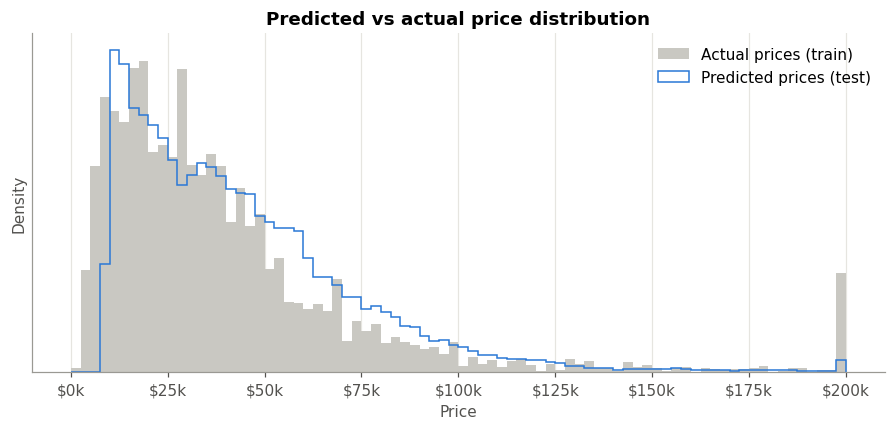

In [36]:
# Distribution of predicted test prices vs actual train prices
fig, ax = plt.subplots(figsize=(10, 4))
bins = np.linspace(0, 200_000, 81)
ax.hist(train['price'].clip(upper=200_000), bins=bins, density=True,
        color=LIGHT_GRAY, label='Actual prices (train)')
ax.hist(submission['price'].clip(upper=200_000), bins=bins, density=True,
        histtype='step', lw=2, color=BLUE, label='Predicted prices (test)')
ax.xaxis.set_major_formatter(dollars)
ax.set(title='Predicted vs actual price distribution', xlabel='Price', ylabel='Density')
ax.set_yticks([])
ax.legend(frameon=False)
plt.show()

**Findings:** the predicted prices have a similar shape to the real ones, but they are more "concentrated" in the middle: the model rarely predicts very cheap or very expensive cars. This is normal for a model trained to minimize RMSE — when unsure, it predicts values closer to the average.

---
## 6. Conclusions
- **Best model:** XGBoost, with a cross-validated RMSE of **≈ \$72,500** (baseline: \$74,600).
- **Feature engineering** from the `engine` text (hp, liters, cylinders) and `car_age` gave the models useful numeric information.
- **Training on log(price) did not help**, because the metric (RMSE) is in dollars and is dominated by the expensive cars.
- **High-cardinality categories** (`model`, `engine`) made LightGBM overfit; converting them to integer codes fixed it.
- The main limitation is the **noise and the outliers** in the price: a few cars cost millions and nothing in the data explains why.
- **Possible improvements:** hyperparameter tuning, target encoding of `model`, and averaging (ensembling) XGBoost + LightGBM.

---
## 7. How each model works (for dummies)

### Baseline (mean)
Imagine guessing the price of every car without looking at it: you'd just say the average price (~\$44k). It is a terrible model, but it gives us a reference: any real model must beat it.

### Ridge (Linear Regression)
Draws the "best straight line" through the data: *price = a × year + b × mileage + c × horsepower + …*. Each feature gets a weight (positive or negative). **Ridge** adds a small penalty so the weights don't become extreme. Simple and fast, but it can't capture complex patterns (e.g., "a Porsche loses value differently than a Toyota").

### Decision tree *(the building block of the next three models)*
A flowchart of yes/no questions: *"Is the car older than 8 years?" → "Mileage above 100k?" → "Is it a luxury brand?"* … At the end of each path there is a price. One tree alone memorizes the data too easily.

### Random Forest
Ask **100 different trees** and take the **average** of their answers — like asking 100 people to estimate the price and averaging. Each tree sees a random sample of cars and features, so their mistakes cancel out.

### Gradient Boosting (LightGBM and XGBoost)
Trees are built **one after another, like a team where each new member fixes the mistakes of the previous ones**. Tree 1 makes a rough guess, tree 2 predicts what tree 1 got wrong, tree 3 corrects what's still wrong, and so on. The final price is the sum of all the small corrections.
- **LightGBM** (Microsoft): very fast, grows trees "leaf by leaf", handles categories natively.
- **XGBoost**: the classic and very popular version, with strong regularization. It was our best model.

---
## 8. Vocabulary index (ML terms used in this notebook)

| Term | Short description |
|---|---|
| **Baseline** | The simplest possible model (here: always predict the mean). Used as a reference to beat. |
| **Categorical feature** | A column with text categories (brand, fuel type), not numbers. |
| **Cardinality (high)** | Number of different categories in a column. *High cardinality* = many (e.g. 1,897 car models). |
| **Cross-validation (K-Fold)** | Split the data in K parts; train K times, each time validating on a different part, and average the scores. |
| **Data leakage** | When information from the validation/test data "leaks" into training, making results look better than they really are. |
| **Early stopping** | Stop adding trees when the validation error stops improving. Prevents overfitting. |
| **EDA** | Exploratory Data Analysis: looking at the data (types, missing values, charts) before modelling. |
| **Ensemble / averaging** | Combining several models' predictions (e.g. the 5 fold models) to get a more stable result. |
| **Feature** | An input column used by the model to predict (year, mileage, hp…). |
| **Feature engineering** | Creating new, more useful features from existing ones (hp from the engine text, car age). |
| **Feature importance** | How much each feature helped the model reduce the error. |
| **Gradient boosting** | Building trees in sequence, each one correcting the errors of the previous ones. |
| **Hyperparameter** | A setting chosen *before* training (number of trees, depth, learning rate). |
| **Learning rate** | How big each correction step is in boosting. Small = slower but more precise. |
| **Log transformation** | Applying log(1 + price) to reduce the skew of the target. `expm1` converts it back. |
| **Missing values (NaN)** | Empty cells in the data. |
| **One-hot encoding** | Turning one text column into several 0/1 columns, one per category. |
| **Outlier** | An extreme value far from the rest (e.g. a \$2.9M car). |
| **Overfitting** | The model memorizes the training data instead of learning general patterns, so it predicts new data badly. |
| **Regularization** | A penalty that keeps the model simpler to avoid overfitting (`alpha` in Ridge, `reg_lambda` in LightGBM). |
| **Regression** | Predicting a number (price), as opposed to classification (predicting a category). |
| **RMSE** | Root Mean Squared Error: √(average of squared errors). In dollars; big errors are punished a lot. |
| **Skewed distribution** | Data with a long tail on one side (many cheap cars, a few very expensive ones). |
| **Target** | The column we want to predict (`price`). |
| **Train / validation / test** | Train = used to learn; validation = used to check the model on unseen data; test = the data we predict for Kaggle. |
| **Tree depth (`max_depth`)** | How many yes/no questions a tree can ask in a row. Deeper = more complex. |